<a href="https://colab.research.google.com/github/jatinchhabra2516-cell/Machine-Learning/blob/main/Lung_Cancer_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("Lung_Cancer_Dataset.csv")

# Display first 5 rows
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 309 non-null    object
 1   AGE                    309 non-null    int64 
 2   SMOKING                309 non-null    int64 
 3   YELLOW_FINGERS         309 non-null    int64 
 4   ANXIETY                309 non-null    int64 
 5   PEER_PRESSURE          309 non-null    int64 
 6   CHRONIC DISEASE        309 non-null    int64 
 7   FATIGUE                309 non-null    int64 
 8   ALLERGY                309 non-null    int64 
 9   WHEEZING               309 non-null    int64 
 10  ALCOHOL CONSUMING      309 non-null    int64 
 11  COUGHING               309 non-null    int64 
 12  SHORTNESS OF BREATH    309 non-null    int64 
 13  SWALLOWING DIFFICULTY  309 non-null    int64 
 14  CHEST PAIN             309 non-null    int64 
 15  LUNG_CANCER            

In [5]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64


In [14]:
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES': 1, 'NO': 0})

In [15]:
print(df.dtypes)

GENDER                   object
AGE                       int64
SMOKING                   int64
YELLOW_FINGERS            int64
ANXIETY                   int64
PEER_PRESSURE             int64
CHRONIC DISEASE           int64
FATIGUE                   int64
ALLERGY                   int64
WHEEZING                  int64
ALCOHOL CONSUMING         int64
COUGHING                  int64
SHORTNESS OF BREATH       int64
SWALLOWING DIFFICULTY     int64
CHEST PAIN                int64
LUNG_CANCER               int64
dtype: object


In [17]:
df['GENDER'] = df['GENDER'].map({'M': 1, 'F': 0})
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES': 1, 'NO': 0})

In [18]:
corr_matrix = df.corr()

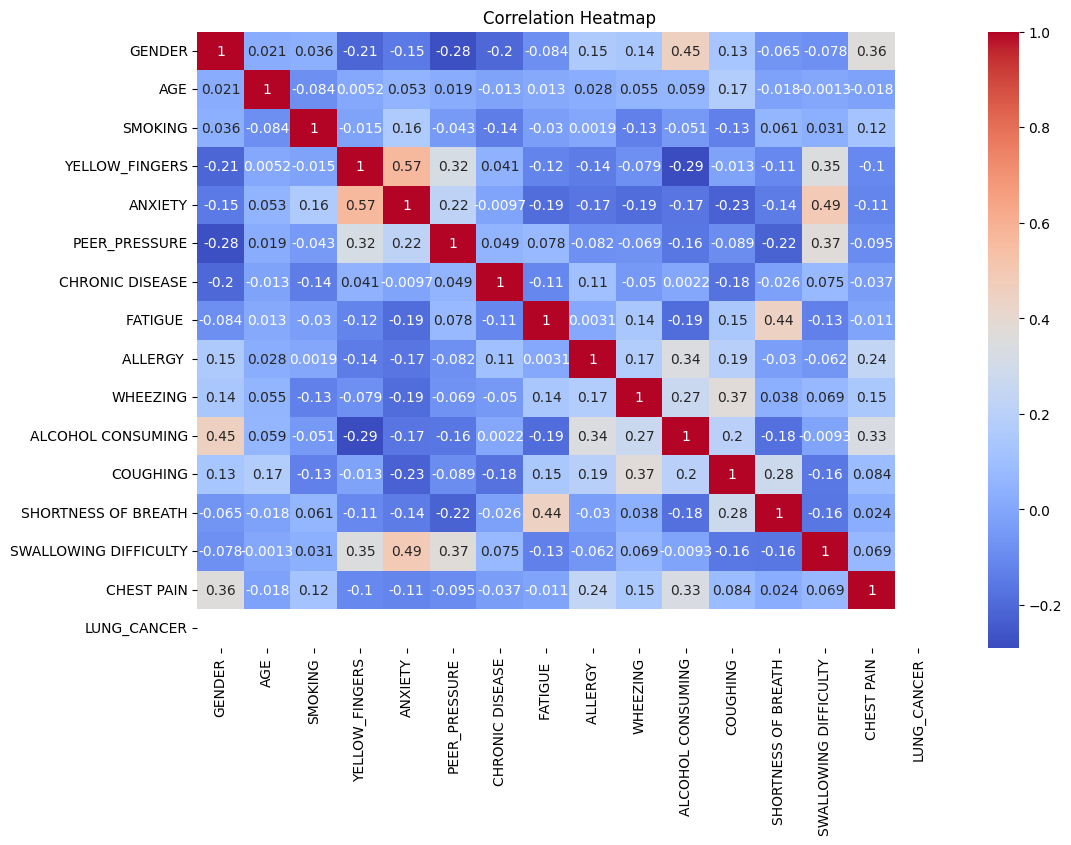

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [20]:
import numpy as np

corr_matrix_abs = corr_matrix.abs()

upper_triangle = corr_matrix_abs.where(
    np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool)
)

to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.9)]

print("Dropped Columns:", to_drop)

df.drop(columns=to_drop, inplace=True)

Dropped Columns: []


In [21]:
target_corr = df.corr()['LUNG_CANCER'].sort_values(ascending=False)

print("Feature Correlation with Target:\n")
print(target_corr)

Feature Correlation with Target:

GENDER                  NaN
AGE                     NaN
SMOKING                 NaN
YELLOW_FINGERS          NaN
ANXIETY                 NaN
PEER_PRESSURE           NaN
CHRONIC DISEASE         NaN
FATIGUE                 NaN
ALLERGY                 NaN
WHEEZING                NaN
ALCOHOL CONSUMING       NaN
COUGHING                NaN
SHORTNESS OF BREATH     NaN
SWALLOWING DIFFICULTY   NaN
CHEST PAIN              NaN
LUNG_CANCER             NaN
Name: LUNG_CANCER, dtype: float64


In [22]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop('LUNG_CANCER', axis=1)
y = df['LUNG_CANCER']

# Split data (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print shapes
print("\nTrain-Test Split Shapes:\n")
print(X_train.shape, X_test.shape)


Train-Test Split Shapes:

(247, 15) (62, 15)


In [34]:
df = pd.read_csv("Lung_Cancer_Dataset.csv")

In [35]:
print(df.isnull().sum())

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64


In [36]:
df['LUNG_CANCER'].fillna(df['LUNG_CANCER'].mode()[0], inplace=True)

/tmp/ipykernel_11808/2147811660.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LUNG_CANCER'].fillna(df['LUNG_CANCER'].mode()[0], inplace=True)


In [37]:
print(df.shape)

(309, 16)


In [38]:
X = df.drop('LUNG_CANCER', axis=1)
y = df['LUNG_CANCER']

In [41]:
# Convert Gender
df['GENDER'] = df['GENDER'].map({'M': 1, 'F': 0})

# Convert target
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES': 1, 'NO': 0})

In [42]:
print(df.dtypes)

GENDER                   int64
AGE                      int64
SMOKING                  int64
YELLOW_FINGERS           int64
ANXIETY                  int64
PEER_PRESSURE            int64
CHRONIC DISEASE          int64
FATIGUE                  int64
ALLERGY                  int64
WHEEZING                 int64
ALCOHOL CONSUMING        int64
COUGHING                 int64
SHORTNESS OF BREATH      int64
SWALLOWING DIFFICULTY    int64
CHEST PAIN               int64
LUNG_CANCER              int64
dtype: object


In [43]:
# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
# See which columns are NOT numeric
non_numeric = X_train.select_dtypes(exclude=['number']).columns
print("Non-numeric columns:", list(non_numeric))
print(X_train[non_numeric].head())

Non-numeric columns: ['GENDER']
    GENDER
126      M
109      M
247      M
234      M
202      M


In [46]:
X_train['GENDER'] = X_train['GENDER'].map({'M': 1, 'F': 0})
X_test['GENDER'] = X_test['GENDER'].map({'M': 1, 'F': 0})

In [47]:
print(X_train.dtypes)

GENDER                   int64
AGE                      int64
SMOKING                  int64
YELLOW_FINGERS           int64
ANXIETY                  int64
PEER_PRESSURE            int64
CHRONIC DISEASE          int64
FATIGUE                  int64
ALLERGY                  int64
WHEEZING                 int64
ALCOHOL CONSUMING        int64
COUGHING                 int64
SHORTNESS OF BREATH      int64
SWALLOWING DIFFICULTY    int64
CHEST PAIN               int64
dtype: object


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**#LOGISTC REGRESSION**

In [49]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [50]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)   # no scaling needed

y_pred_rf = rf.predict(X_test)

In [52]:
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression:", acc_lr)
print("SVM:", acc_svm)
print("Random Forest:", acc_rf)

Logistic Regression: 0.967741935483871
SVM: 0.967741935483871
Random Forest: 0.967741935483871


In [53]:
from sklearn.metrics import confusion_matrix

print("\nLogistic Regression CM:\n", confusion_matrix(y_test, y_pred_lr))
print("\nSVM CM:\n", confusion_matrix(y_test, y_pred_svm))
print("\nRandom Forest CM:\n", confusion_matrix(y_test, y_pred_rf))


Logistic Regression CM:
 [[ 1  1]
 [ 1 59]]

SVM CM:
 [[ 1  1]
 [ 1 59]]

Random Forest CM:
 [[ 1  1]
 [ 1 59]]


**Logistic Regression Tuning**

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

c_values = [0.01, 0.1, 1, 5, 10]

print("Logistic Regression Tuning:\n")

for c in c_values:
    lr = LogisticRegression(C=c, solver='lbfgs', max_iter=1000)
    lr.fit(X_train_scaled, y_train)

    y_pred = lr.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    print(f"C={c}, Accuracy={acc}")

Logistic Regression Tuning:

C=0.01, Accuracy=0.967741935483871
C=0.1, Accuracy=0.967741935483871
C=1, Accuracy=0.967741935483871
C=5, Accuracy=0.9838709677419355
C=10, Accuracy=0.9838709677419355


**Random Forest Tuning**

In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

depths = [3, 5, 8, None]

print("Random Forest Tuning:\n")

for d in depths:
    rf = RandomForestClassifier(max_depth=d, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Max Depth={d}, Accuracy={acc}")

Random Forest Tuning:

Max Depth=3, Accuracy=0.9838709677419355
Max Depth=5, Accuracy=0.967741935483871
Max Depth=8, Accuracy=0.967741935483871
Max Depth=None, Accuracy=0.967741935483871


**SVM Tuning**

In [56]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

c_values = [0.1, 1, 10]

print("SVM Tuning:\n")

for c in c_values:
    svm = SVC(C=c)
    svm.fit(X_train_scaled, y_train)

    y_pred = svm.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    print(f"C={c}, Accuracy={acc}")

SVM Tuning:

C=0.1, Accuracy=0.967741935483871
C=1, Accuracy=0.967741935483871
C=10, Accuracy=0.9516129032258065


In [57]:
baseline_lr = 0.967741935483871
baseline_svm = 0.967741935483871
baseline_rf = 0.967741935483871

In [58]:
lr_tuned = LogisticRegression(C=5, solver='lbfgs', max_iter=1000)
lr_tuned.fit(X_train_scaled, y_train)

y_pred_lr_tuned = lr_tuned.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
tuned_lr = accuracy_score(y_test, y_pred_lr_tuned)

In [59]:
svm_tuned = SVC(C=1)
svm_tuned.fit(X_train_scaled, y_train)

y_pred_svm_tuned = svm_tuned.predict(X_test_scaled)

tuned_svm = accuracy_score(y_test, y_pred_svm_tuned)

In [60]:
rf_tuned = RandomForestClassifier(max_depth=3, random_state=42)
rf_tuned.fit(X_train, y_train)

y_pred_rf_tuned = rf_tuned.predict(X_test)

tuned_rf = accuracy_score(y_test, y_pred_rf_tuned)

In [61]:
imp_lr = tuned_lr - baseline_lr
imp_svm = tuned_svm - baseline_svm
imp_rf = tuned_rf - baseline_rf

In [62]:
print("Logistic Regression:", baseline_lr, tuned_lr, imp_lr)
print("SVM:", baseline_svm, tuned_svm, imp_svm)
print("Random Forest:", baseline_rf, tuned_rf, imp_rf)

Logistic Regression: 0.967741935483871 0.9838709677419355 0.016129032258064502
SVM: 0.967741935483871 0.967741935483871 0.0
Random Forest: 0.967741935483871 0.9838709677419355 0.016129032258064502
